# True Flower-based Federated LoRA Simulation (Colab)

This notebook uses **Flower's real simulation API** with Hugging Face + PEFT LoRA adapters.

It runs a federated fine-tuning pipeline where:
- each Flower client owns its own data shard
- only **LoRA adapter weights** are exchanged
- Flower runs **FedAvg**
- the notebook records per-round metrics and produces plots

Recommended runtime:
- **Colab Pro GPU**
- for `meta-llama/Llama-3.2-1B-Instruct`, accept the Hugging Face license and set `HF_TOKEN`
- start with **`microsoft/phi-2`** if you want fewer gating issues

In [1]:
# Install dependencies
!pip -q install -U flwr "flwr[simulation]" transformers datasets accelerate peft bitsandbytes evaluate pandas matplotlib scikit-learn sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 157.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 152.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323

## Configuration

Change the model here if you want:
- `microsoft/phi-2`
- `meta-llama/Llama-3.2-1B-Instruct`

In [2]:
import os
import math
import time
import json
import random
import gc
from dataclasses import dataclass, asdict
from collections import defaultdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType, PeftModel
import flwr as fl
from flwr.server.strategy import FedAvg
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# Main experiment settings
# -------------------------
MODEL_NAME = "microsoft/phi-2"   # or "meta-llama/Llama-3.2-1B-Instruct"
DATASET_NAME = "vicgalle/alpaca-gpt4"

NUM_CLIENTS = 8
CLIENTS_PER_ROUND = 4
ROUNDS = 6
LOCAL_EPOCHS = 1
BATCH_SIZE = 2
MAX_LENGTH = 256
LEARNING_RATE = 2e-4

MAX_TRAIN_SAMPLES = 800
MAX_VAL_SAMPLES = 200

PARTITION_MODE = "non_iid"   # "iid" or "non_iid"
RUN_NAME = "flower_phi2_non_iid"

# QLoRA-ish settings
LOAD_IN_4BIT = True
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

HF_TOKEN = os.environ.get("HF_TOKEN", None)

print("torch:", torch.__version__)
print("flower:", fl.__version__)
print("device available:", "cuda" if torch.cuda.is_available() else "cpu")

torch: 2.10.0+cu128
flower: 1.27.0
device available: cuda


## Dataset formatting

In [3]:
def format_alpaca(example: Dict[str, str]) -> Dict[str, str]:
    instruction = (example.get("instruction") or "").strip()
    input_text = (example.get("input") or "").strip()
    output_text = (example.get("output") or "").strip()

    if input_text:
        prompt = (
            "### Instruction:\n"
            f"{instruction}\n\n"
            "### Input:\n"
            f"{input_text}\n\n"
            "### Response:\n"
        )
    else:
        prompt = (
            "### Instruction:\n"
            f"{instruction}\n\n"
            "### Response:\n"
        )
    full_text = prompt + output_text
    group_key = "short" if len(output_text.split()) < 40 else "long"
    if "code" in instruction.lower() or "python" in output_text.lower():
        group_key = "code"

    return {
        "prompt": prompt,
        "response": output_text,
        "full_text": full_text,
        "instruction_len": len(instruction.split()),
        "response_len": len(output_text.split()),
        "total_len": len(full_text.split()),
        "group_key": group_key,
    }

raw = load_dataset(DATASET_NAME, split="train", token=HF_TOKEN)
raw = raw.shuffle(seed=SEED)
subset = raw.select(range(MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES))
formatted = [format_alpaca(row) for row in subset]

train_examples = formatted[:MAX_TRAIN_SAMPLES]
val_examples = formatted[MAX_TRAIN_SAMPLES:MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES]

display(pd.DataFrame(train_examples[:3]))
print("train examples:", len(train_examples))
print("val examples:  ", len(val_examples))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-6ef3991c06080e(…):   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

,prompt,response,full_text,instruction_len,response_len,total_len,group_key
0,### Instruction:\nWhat would be the best type ...,"If a person has arthritis, low-impact exercise...",### Instruction:\nWhat would be the best type ...,14,181,199,long
1,### Instruction:\nCalculate the atomic mass fo...,The atomic mass of lithium is 6.941 u. The ato...,### Instruction:\nCalculate the atomic mass fo...,6,93,103,long
2,### Instruction:\nConvert the following binary...,uaurit,### Instruction:\nConvert the following binary...,8,1,20,code


train examples: 800
val examples:   200


## Partition the data into simulated Flower clients

In [4]:
def partition_examples(
    examples: List[Dict],
    num_clients: int,
    mode: str = "iid",
) -> Dict[str, List[Dict]]:
    client_map = {str(i): [] for i in range(num_clients)}

    if mode == "iid":
        shuffled = examples[:]
        random.shuffle(shuffled)
        for i, ex in enumerate(shuffled):
            client_map[str(i % num_clients)].append(ex)
        return client_map

    # non-iid: bucket by group_key, then assign buckets unevenly
    grouped = defaultdict(list)
    for ex in examples:
        grouped[ex["group_key"]].append(ex)

    keys = sorted(grouped.keys())
    for k in keys:
        random.shuffle(grouped[k])

    client_prefs = {}
    for i in range(num_clients):
        client_prefs[str(i)] = keys[i % len(keys)]

    leftovers = []
    for cid, pref in client_prefs.items():
        chunk = grouped[pref]
        take = max(1, len(chunk) // max(1, num_clients // len(keys)))
        client_map[cid].extend(chunk[:take])
        grouped[pref] = chunk[take:]

    for k, vals in grouped.items():
        leftovers.extend(vals)

    random.shuffle(leftovers)
    for i, ex in enumerate(leftovers):
        client_map[str(i % num_clients)].append(ex)

    return client_map

train_client_map = partition_examples(train_examples, NUM_CLIENTS, PARTITION_MODE)
val_client_map = partition_examples(val_examples, NUM_CLIENTS, PARTITION_MODE)

summary_rows = []
for cid in sorted(train_client_map.keys()):
    train_lens = [x["total_len"] for x in train_client_map[cid]]
    val_lens = [x["total_len"] for x in val_client_map[cid]]
    summary_rows.append({
        "client_id": cid,
        "train_samples": len(train_client_map[cid]),
        "val_samples": len(val_client_map[cid]),
        "avg_train_len": np.mean(train_lens) if train_lens else 0,
        "avg_val_len": np.mean(val_lens) if val_lens else 0,
    })

partition_df = pd.DataFrame(summary_rows)
display(partition_df)

,client_id,train_samples,val_samples,avg_train_len,avg_val_len
0,0,30,8,121.866667,113.000000
1,1,261,72,178.727969,185.347222
2,2,161,32,47.577640,42.500000
3,3,23,6,97.000000,233.000000
4,4,138,38,164.391304,172.631579
5,5,89,18,45.741573,51.055556
6,6,20,5,149.050000,182.200000
7,7,78,21,156.320513,190.238095


## Tokenizer and helper functions

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_examples(examples: List[Dict]) -> Dataset:
    ds = Dataset.from_list(examples)

    def tok(batch):
        out = tokenizer(
            batch["full_text"],
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
        )
        out["labels"] = out["input_ids"].copy()
        return out

    ds = ds.map(tok, batched=True, remove_columns=ds.column_names)
    return ds

DATA_COLLATOR = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

def compute_token_accuracy(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    mask = labels != -100
    correct = ((preds == labels) & mask).sum()
    total = mask.sum()
    return {"token_accuracy": float(correct / max(total, 1))}

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

## Build the base PEFT model

This is the base model construction used by each Flower client.

In [6]:
def choose_lora_targets(model_name: str):
    # Broad defaults that work for Phi/Llama-style decoder models
    # Adjust if needed for a specific model architecture.
    if "phi" in model_name.lower():
        return ["q_proj", "k_proj", "v_proj", "dense", "fc1", "fc2"]
    if "llama" in model_name.lower():
        return ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    return ["c_attn", "c_proj"]

def build_peft_model():
    quant_config = None
    model_kwargs = {}
    if LOAD_IN_4BIT:
        from transformers import BitsAndBytesConfig
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        model_kwargs["quantization_config"] = quant_config
        model_kwargs["device_map"] = "auto"
    else:
        model_kwargs["torch_dtype"] = torch.float16 if torch.cuda.is_available() else torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        token=HF_TOKEN,
        trust_remote_code=True,
        **model_kwargs,
    )

    if LOAD_IN_4BIT:
        model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        target_modules=choose_lora_targets(MODEL_NAME),
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# Smoke test
tmp_model = build_peft_model()
del tmp_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


## LoRA adapter weight helpers

Only LoRA weights are exchanged through Flower.

In [7]:
def get_lora_state_dict(model) -> Dict[str, torch.Tensor]:
    state = model.state_dict()
    lora_state = {k: v.detach().cpu() for k, v in state.items() if "lora_" in k}
    return lora_state

def set_lora_state_dict(model, lora_state: Dict[str, torch.Tensor]):
    current = model.state_dict()
    for k, v in lora_state.items():
        if k in current:
            current[k] = v.to(current[k].device).type_as(current[k])
    model.load_state_dict(current, strict=False)

LORA_KEY_ORDER = None

def state_dict_to_ndarrays(state: Dict[str, torch.Tensor]) -> List[np.ndarray]:
    global LORA_KEY_ORDER
    keys = sorted(state.keys())
    if LORA_KEY_ORDER is None:
        LORA_KEY_ORDER = keys
    return [state[k].cpu().numpy() for k in LORA_KEY_ORDER]

def ndarrays_to_state_dict(arrs: List[np.ndarray]) -> Dict[str, torch.Tensor]:
    return {k: torch.tensor(v) for k, v in zip(LORA_KEY_ORDER, arrs)}

## Flower client definition

This is the part that makes the notebook **true Flower-based simulation**.

In [8]:
@dataclass
class ClientConfig:
    client_id: str
    train_examples: List[Dict]
    val_examples: List[Dict]

CLIENT_DATA: Dict[str, ClientConfig] = {
    cid: ClientConfig(cid, train_client_map[cid], val_client_map[cid])
    for cid in train_client_map.keys()
}

ROUND_METRICS = []

class LoraFlowerClient(fl.client.NumPyClient):
    def __init__(self, client_id: str):
        self.client_id = client_id
        self.client_cfg = CLIENT_DATA[client_id]
        self.model = None

    def _ensure_model(self):
        if self.model is None:
            self.model = build_peft_model()

    def get_parameters(self, config):
        self._ensure_model()
        lora_state = get_lora_state_dict(self.model)
        return state_dict_to_ndarrays(lora_state)

    def fit(self, parameters, config):
        self._ensure_model()

        # Load latest global LoRA weights
        if parameters is not None and len(parameters) > 0:
            state = ndarrays_to_state_dict(parameters)
            set_lora_state_dict(self.model, state)

        train_ds = tokenize_examples(self.client_cfg.train_examples)
        val_ds = tokenize_examples(self.client_cfg.val_examples)

        args = TrainingArguments(
            output_dir=f"./tmp_client_{self.client_id}",
            num_train_epochs=LOCAL_EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            logging_steps=10,
            eval_strategy="epoch",
            save_strategy="no",
            report_to=[],
            fp16=torch.cuda.is_available(),
            remove_unused_columns=False,
        )

        trainer = Trainer(
            model=self.model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            data_collator=DATA_COLLATOR,
            compute_metrics=compute_token_accuracy,
        )

        start = time.time()
        train_result = trainer.train()
        eval_result = trainer.evaluate()
        elapsed = time.time() - start

        lora_state = get_lora_state_dict(self.model)
        params = state_dict_to_ndarrays(lora_state)

        num_examples = len(train_ds)

        metrics = {
            "client_id": self.client_id,
            "train_loss": float(train_result.training_loss),
            "eval_loss": float(eval_result.get("eval_loss", np.nan)),
            "token_accuracy": float(eval_result.get("eval_token_accuracy", np.nan)),
            "round_time_sec": float(elapsed),
            "comm_bytes": float(sum(arr.nbytes for arr in params) * 2),  # down + up
        }

        return params, num_examples, metrics

    def evaluate(self, parameters, config):
        self._ensure_model()
        if parameters is not None and len(parameters) > 0:
            state = ndarrays_to_state_dict(parameters)
            set_lora_state_dict(self.model, state)

        val_ds = tokenize_examples(self.client_cfg.val_examples)

        args = TrainingArguments(
            output_dir=f"./tmp_eval_{self.client_id}",
            per_device_eval_batch_size=BATCH_SIZE,
            report_to=[],
            fp16=torch.cuda.is_available(),
            remove_unused_columns=False,
        )

        trainer = Trainer(
            model=self.model,
            args=args,
            eval_dataset=val_ds,
            data_collator=DATA_COLLATOR,
            compute_metrics=compute_token_accuracy,
        )
        eval_result = trainer.evaluate()
        loss = float(eval_result.get("eval_loss", np.nan))
        return loss, len(val_ds), {
            "eval_loss": loss,
            "token_accuracy": float(eval_result.get("eval_token_accuracy", np.nan)),
        }

def client_fn(context: fl.common.Context):
    cid = context.node_config["partition-id"]
    return LoraFlowerClient(str(cid)).to_client()

## Flower aggregation helpers and strategy

In [9]:
def weighted_average(metrics: List[Tuple[int, Dict[str, float]]]) -> Dict[str, float]:
    # metrics = [(num_examples, metrics_dict), ...]
    total_examples = sum(num_examples for num_examples, _ in metrics)
    if total_examples == 0:
        return {}

    agg = defaultdict(float)
    client_eval_losses = []

    for num_examples, m in metrics:
        w = num_examples / total_examples
        for k, v in m.items():
            if isinstance(v, (int, float)):
                agg[k] += w * float(v)
        if "eval_loss" in m:
            client_eval_losses.append(float(m["eval_loss"]))

    if client_eval_losses:
        agg["client_val_loss_gap"] = float(max(client_eval_losses) - min(client_eval_losses))

    if "eval_loss" in agg:
        agg["perplexity"] = float(math.exp(min(20.0, agg["eval_loss"])))

    return dict(agg)

HISTORY_ROWS = []

class MetricsFedAvg(FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)

        round_metrics = []
        for client_proxy, fit_res in results:
            round_metrics.append((fit_res.num_examples, fit_res.metrics))

        agg = weighted_average(round_metrics)
        agg["round"] = server_round
        agg["phase"] = "fit"
        HISTORY_ROWS.append(agg)

        return aggregated_parameters, agg

    def aggregate_evaluate(self, server_round, results, failures):
        loss_agg, metrics_agg = super().aggregate_evaluate(server_round, results, failures)

        eval_metrics = []
        for client_proxy, eval_res in results:
            eval_metrics.append((eval_res.num_examples, eval_res.metrics))

        agg = weighted_average(eval_metrics)
        agg["round"] = server_round
        agg["phase"] = "evaluate"
        if loss_agg is not None:
            agg["global_eval_loss"] = float(loss_agg)
            agg["global_perplexity"] = float(math.exp(min(20.0, loss_agg)))
        HISTORY_ROWS.append(agg)

        return loss_agg, agg

## Initialize the global LoRA weights

In [10]:
init_model = build_peft_model()
initial_lora = get_lora_state_dict(init_model)
initial_parameters = ndarrays_to_parameters(state_dict_to_ndarrays(initial_lora))

del init_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


## Run a true Flower simulation

In [11]:
backend_config = {
    "client_resources": {
        "num_cpus": 2,
        "num_gpus": 1.0 if torch.cuda.is_available() else 0.0,
    }
}

strategy = MetricsFedAvg(
    fraction_fit=CLIENTS_PER_ROUND / NUM_CLIENTS,
    fraction_evaluate=CLIENTS_PER_ROUND / NUM_CLIENTS,
    min_fit_clients=CLIENTS_PER_ROUND,
    min_evaluate_clients=CLIENTS_PER_ROUND,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=initial_parameters,
    fit_metrics_aggregation_fn=weighted_average,
    evaluate_metrics_aggregation_fn=weighted_average,
)

start = time.time()

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=ROUNDS),
    strategy=strategy,
    client_resources=backend_config["client_resources"],
    actor_kwargs={
        "on_actor_init_fn": lambda: None,
    },
)

elapsed_total = time.time() - start
print(f"Simulation done in {elapsed_total/60:.2f} minutes")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Map: 100%|██████████| 6/6 [00:00<00:00, 779.10 examples/s]
(ClientAppActor pid=10206) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
(ClientAppActor pid=10206)   return data.pin_memory(device)
(ClientAppActor pid=10206) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
(ClientAppActor pid=10206)   return data.pin_memory(device)
Loading weights: 100%|██████████| 453/453 [00:01<00:00, 285.66it/s]


(ClientAppActor pid=10206) trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


Map: 100%|██████████| 32/32 [00:00<00:00, 2291.77 examples/s]
(ClientAppActor pid=10206) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
(ClientAppActor pid=10206)   return data.pin_memory(device)
(ClientAppActor pid=10206) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
(ClientAppActor pid=10206)   return data.pin_memory(device)
100%|██████████| 16/16 [00:02<00:00,  6.10it/s]
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 6 round(s) in 1302.76s
INFO :      	History (loss, distri

Simulation done in 21.95 minutes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Inspect Flower history and round metrics

In [12]:
hist_df = pd.DataFrame(HISTORY_ROWS).sort_values(["round", "phase"]).reset_index(drop=True)
display(hist_df.tail(12))

summary = {}
fit_only = hist_df[hist_df["phase"] == "fit"].copy()
eval_only = hist_df[hist_df["phase"] == "evaluate"].copy()

if len(fit_only):
    last_fit = fit_only.iloc[-1].to_dict()
    summary["final_round"] = int(last_fit["round"])
    summary["final_train_loss"] = float(last_fit.get("train_loss", np.nan))
    summary["final_val_loss"] = float(last_fit.get("eval_loss", np.nan))
    summary["final_perplexity"] = float(last_fit.get("perplexity", np.nan))
    summary["total_comm_bytes"] = float(fit_only["comm_bytes"].sum())
    summary["client_val_loss_gap"] = float(last_fit.get("client_val_loss_gap", np.nan))
    summary["avg_round_time_sec"] = float(fit_only["round_time_sec"].mean())
    summary["num_clients_observed"] = int(CLIENTS_PER_ROUND)

print(json.dumps(summary, indent=2))

,train_loss,eval_loss,token_accuracy,round_time_sec,comm_bytes,client_val_loss_gap,perplexity,round,phase,global_eval_loss,global_perplexity
0,NaN,1.007832,0.026342,NaN,NaN,0.515491,2.739656,1,evaluate,1.007832,2.739656
1,1.085030,0.974465,0.023216,47.751482,94371840.0,0.787359,2.649748,1,fit,NaN,NaN
2,NaN,1.014454,0.018100,NaN,NaN,0.388516,2.757857,2,evaluate,1.014454,2.757857
3,1.038217,0.994627,0.017478,68.806975,94371840.0,0.457651,2.703716,2,fit,NaN,NaN
4,NaN,1.012617,0.018399,NaN,NaN,0.387840,2.752797,3,evaluate,1.012617,2.752797
5,0.948607,0.942528,0.021051,69.647604,94371840.0,0.229989,2.566461,3,fit,NaN,NaN
6,NaN,0.909040,0.025978,NaN,NaN,0.291516,2.481938,4,evaluate,0.909040,2.481938
7,0.966325,0.998900,0.018932,65.049371,94371840.0,0.194345,2.715294,4,fit,NaN,NaN
8,NaN,0.988964,0.018758,NaN,NaN,0.197414,2.688448,5,evaluate,0.988964,2.688448
9,0.919465,1.019166,0.020376,36.869292,94371840.0,0.116359,2.770882,5,fit,NaN,NaN


{
  "final_round": 6,
  "final_train_loss": 0.8659077677604503,
  "final_val_loss": 0.9587895783306599,
  "final_perplexity": 2.6085371318714197,
  "total_comm_bytes": 566231040.0,
  "client_val_loss_gap": 0.22285419702529907,
  "avg_round_time_sec": 59.820495328435356,
  "num_clients_observed": 4
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Plots

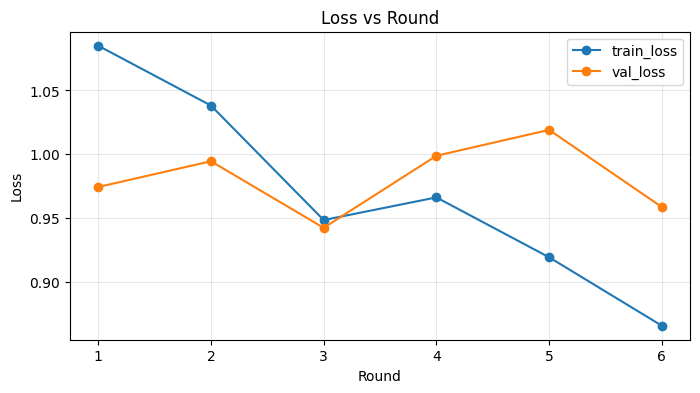

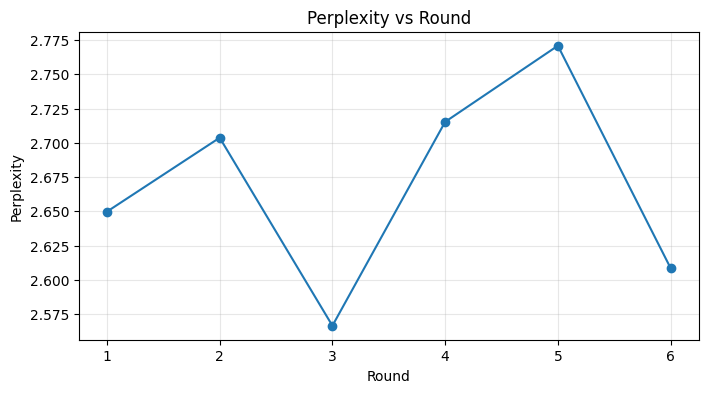

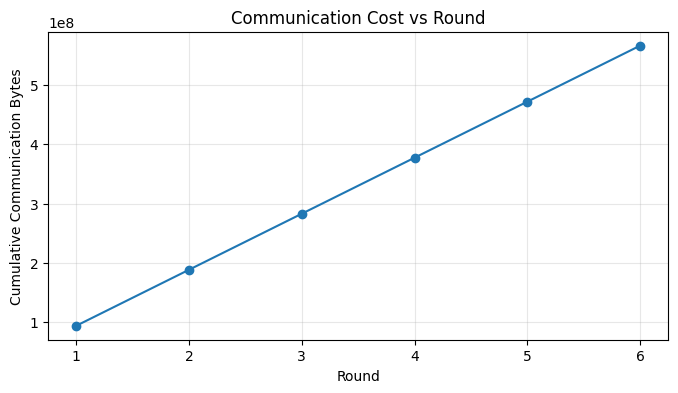

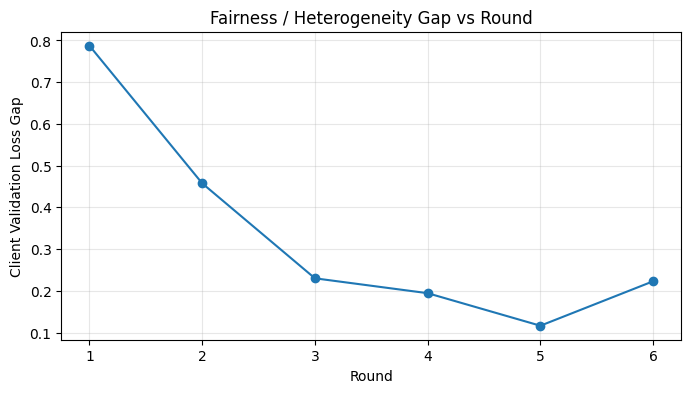

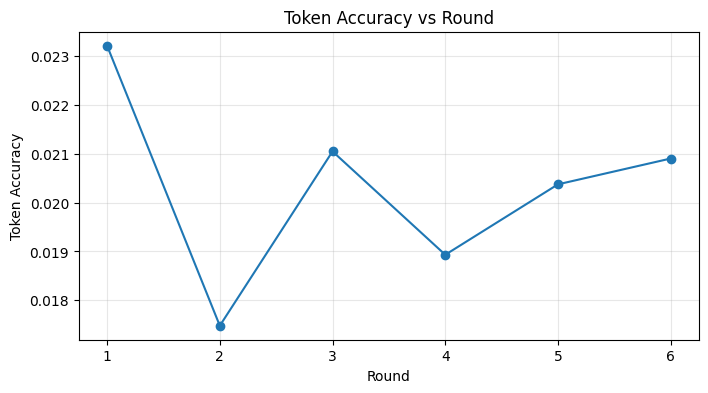

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(fit_only["round"], fit_only["train_loss"], marker="o", label="train_loss")
plt.plot(fit_only["round"], fit_only["eval_loss"], marker="o", label="val_loss")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.title("Loss vs Round")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fit_only["round"], fit_only["perplexity"], marker="o")
plt.xlabel("Round")
plt.ylabel("Perplexity")
plt.title("Perplexity vs Round")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fit_only["round"], fit_only["comm_bytes"].cumsum(), marker="o")
plt.xlabel("Round")
plt.ylabel("Cumulative Communication Bytes")
plt.title("Communication Cost vs Round")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fit_only["round"], fit_only["client_val_loss_gap"], marker="o")
plt.xlabel("Round")
plt.ylabel("Client Validation Loss Gap")
plt.title("Fairness / Heterogeneity Gap vs Round")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fit_only["round"], fit_only["token_accuracy"], marker="o")
plt.xlabel("Round")
plt.ylabel("Token Accuracy")
plt.title("Token Accuracy vs Round")
plt.grid(True, alpha=0.3)
plt.show()

## Multi-experiment runner

Use this to compare:
- IID baseline
- Non-IID baseline
- High client fraction
- More rounds

In [14]:
def run_experiment(
    run_name: str,
    partition_mode: str,
    clients_per_round: int,
    rounds: int,
):
    global CLIENT_DATA, HISTORY_ROWS, LORA_KEY_ORDER

    train_map = partition_examples(train_examples, NUM_CLIENTS, partition_mode)
    val_map = partition_examples(val_examples, NUM_CLIENTS, partition_mode)

    CLIENT_DATA = {
        cid: ClientConfig(cid, train_map[cid], val_map[cid])
        for cid in train_map.keys()
    }

    HISTORY_ROWS = []
    LORA_KEY_ORDER = None

    init_model = build_peft_model()
    initial_lora = get_lora_state_dict(init_model)
    init_params = ndarrays_to_parameters(state_dict_to_ndarrays(initial_lora))
    del init_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    strategy = MetricsFedAvg(
        fraction_fit=clients_per_round / NUM_CLIENTS,
        fraction_evaluate=clients_per_round / NUM_CLIENTS,
        min_fit_clients=clients_per_round,
        min_evaluate_clients=clients_per_round,
        min_available_clients=NUM_CLIENTS,
        initial_parameters=init_params,
        fit_metrics_aggregation_fn=weighted_average,
        evaluate_metrics_aggregation_fn=weighted_average,
    )

    start = time.time()
    fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=rounds),
        strategy=strategy,
        client_resources={"num_cpus": 2, "num_gpus": 1.0 if torch.cuda.is_available() else 0.0},
        actor_kwargs={"on_actor_init_fn": lambda: None},
    )
    runtime = time.time() - start

    hist = pd.DataFrame(HISTORY_ROWS)
    fit_hist = hist[hist["phase"] == "fit"].copy()
    last = fit_hist.iloc[-1].to_dict()

    return {
        "run": run_name,
        "partition": partition_mode,
        "clients_per_round": clients_per_round,
        "rounds": rounds,
        "final_round": int(last["round"]),
        "final_train_loss": float(last.get("train_loss", np.nan)),
        "final_val_loss": float(last.get("eval_loss", np.nan)),
        "final_perplexity": float(last.get("perplexity", np.nan)),
        "final_token_accuracy": float(last.get("token_accuracy", np.nan)),
        "total_comm_bytes": float(fit_hist["comm_bytes"].sum()),
        "client_val_loss_gap": float(last.get("client_val_loss_gap", np.nan)),
        "avg_round_time_sec": float(fit_hist["round_time_sec"].mean()),
        "runtime_sec": float(runtime),
    }

experiment_specs = [
    ("iid_baseline", "iid", 4, 6),
    ("non_iid_baseline", "non_iid", 4, 6),
    ("high_client_fraction", "non_iid", 6, 6),
    ("more_rounds_non_iid", "non_iid", 4, 10),
]

all_results = []
for name, part, cpr, rnds in experiment_specs:
    print(f"Running {name} ...")
    res = run_experiment(name, part, cpr, rnds)
    all_results.append(res)
    print(json.dumps(res, indent=2))

Running iid_baseline ...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=6, no round_timeout
2026-03-26 01:18:58,871	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'accelerator_type:A100': 1.0, 'memory': 623740

(ClientAppActor pid=17336) trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


...

Map: 100%|██████████| 21/21 [00:00<00:00, 1135.39 examples/s]
(ClientAppActor pid=38271) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
(ClientAppActor pid=38271)   return data.pin_memory(device)
(ClientAppActor pid=38271) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
(ClientAppActor pid=38271)   return data.pin_memory(device)
Loading weights: 100%|██████████| 453/453 [00:01<00:00, 286.82it/s]


(ClientAppActor pid=38271) trainable params: 11,796,480 || all params: 2,791,480,320 || trainable%: 0.4226


Map: 100%|██████████| 8/8 [00:00<00:00, 996.15 examples/s]
(ClientAppActor pid=38271) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
(ClientAppActor pid=38271)   return data.pin_memory(device)
(ClientAppActor pid=38271) /usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
(ClientAppActor pid=38271)   return data.pin_memory(device)
100%|██████████| 4/4 [00:00<00:00,  7.85it/s]
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 1798.79s
INFO :      	History (loss, distribute

{
  "run": "more_rounds_non_iid",
  "partition": "non_iid",
  "clients_per_round": 4,
  "rounds": 10,
  "final_round": 10,
  "final_train_loss": 0.7830616009330709,
  "final_val_loss": 0.9985996198586443,
  "final_perplexity": 2.714477864687177,
  "final_token_accuracy": 0.024928985296023536,
  "total_comm_bytes": 943718400.0,
  "client_val_loss_gap": 0.25872963666915894,
  "avg_round_time_sec": 53.34404555280364,
  "runtime_sec": 1807.7808899879456
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Compare experiment results

,run,partition,clients_per_round,rounds,final_round,final_train_loss,final_val_loss,final_perplexity,final_token_accuracy,total_comm_bytes,client_val_loss_gap,avg_round_time_sec,runtime_sec
0,iid_baseline,iid,4,6,6,0.937637,0.990431,2.692395,0.018279,566231040.0,0.053478,36.460037,1139.168715
1,non_iid_baseline,non_iid,4,6,6,0.863885,1.020288,2.773993,0.019080,566231040.0,0.292026,57.358915,1080.820402
2,high_client_fraction,non_iid,6,6,6,0.887556,0.992641,2.698353,0.022131,566231040.0,0.213208,54.922858,1617.698425
3,more_rounds_non_iid,non_iid,4,10,10,0.783062,0.998600,2.714478,0.024929,943718400.0,0.258730,53.344046,1807.780890


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


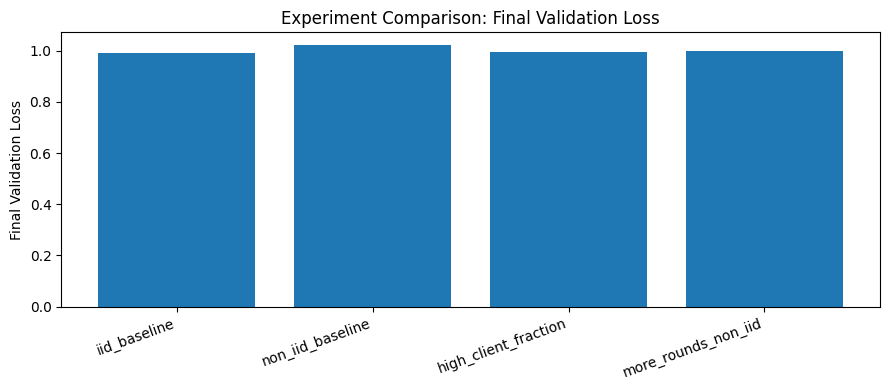

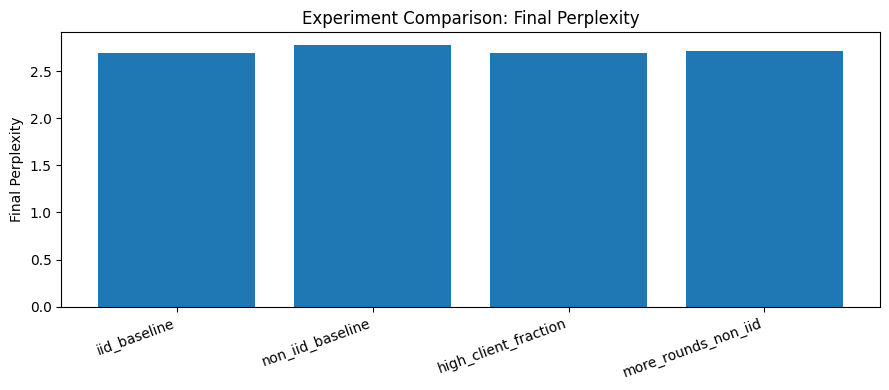

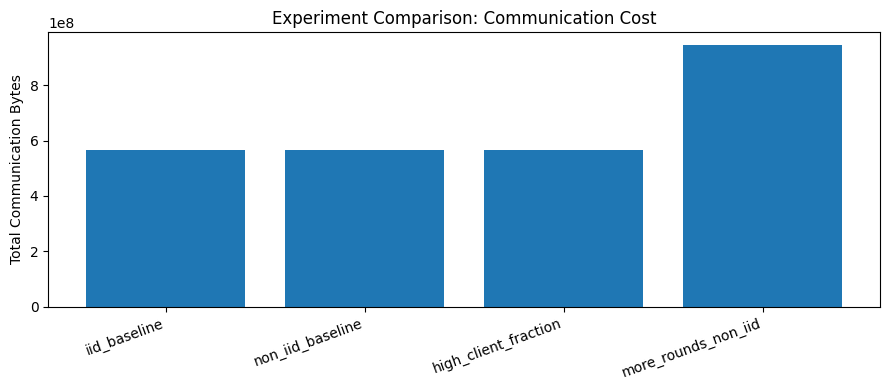

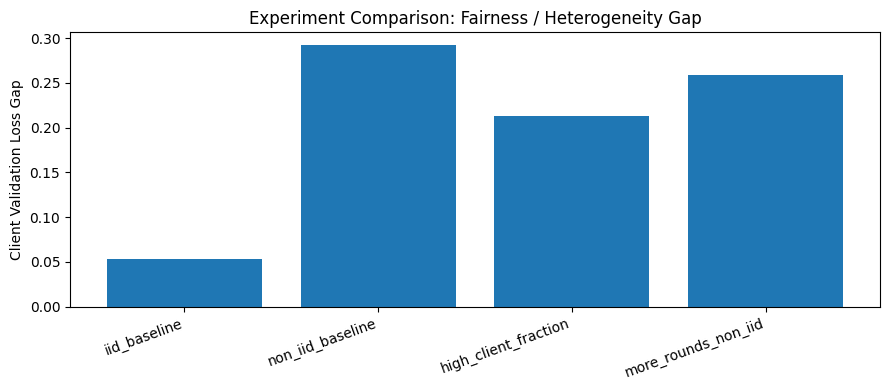

In [15]:
results_df = pd.DataFrame(all_results)
display(results_df)

plt.figure(figsize=(9, 4))
plt.bar(results_df["run"], results_df["final_val_loss"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Final Validation Loss")
plt.title("Experiment Comparison: Final Validation Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(results_df["run"], results_df["final_perplexity"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Final Perplexity")
plt.title("Experiment Comparison: Final Perplexity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(results_df["run"], results_df["total_comm_bytes"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Total Communication Bytes")
plt.title("Experiment Comparison: Communication Cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(results_df["run"], results_df["client_val_loss_gap"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Client Validation Loss Gap")
plt.title("Experiment Comparison: Fairness / Heterogeneity Gap")
plt.tight_layout()
plt.show()

## Save outputs

In [16]:
os.makedirs("flower_outputs", exist_ok=True)
results_df.to_csv("flower_outputs/experiment_results.csv", index=False)
with open("flower_outputs/experiment_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

if len(hist_df):
    hist_df.to_csv("flower_outputs/round_metrics_last_run.csv", index=False)

print("Saved:")
print("- flower_outputs/experiment_results.csv")
print("- flower_outputs/experiment_results.json")
print("- flower_outputs/round_metrics_last_run.csv")

Saved:
- flower_outputs/experiment_results.csv
- flower_outputs/experiment_results.json
- flower_outputs/round_metrics_last_run.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
